In [2]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from ml_enhance import FeatureImportance
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
HuberReg_combo_filtered_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_combo_filtered_results.pkl"), "HuberReg_topo+QM_filtered")
HuberReg_topo_filtered_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_topo_filtered_results.pkl"), "HuberReg_topo_filtered")

In [4]:
HuberReg_combo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_combo_relevant_results.pkl"), "HuberReg_topo+QM_relevant")
HuberReg_topo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_topo_relevant_results.pkl"), "HuberReg_topo_relevant")

In [5]:
KRR_topo_filtered_df = load_hpc_result(Path("../data/KRR_results/KRR_topo_filtered_results.pkl"), "KRR_topo_filtered")
KRR_combo_filtered_df = load_hpc_result(Path("../data/KRR_results/KRR_combo_filtered_results.pkl"), "KRR_topo+QM_filtered")

In [6]:
KRR_combo_relevant_df = load_hpc_result(Path("../data/KRR_results/KRR_combo_relevant_results.pkl"), "KRR_topo+QM_relevant")
KRR_topo_relevant_df = load_hpc_result(Path("../data/KRR_results/KRR_topo_relevant_results.pkl"), "KRR_topo_relevant")

In [7]:
KRR_combo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_no_norm_results.pkl"), "KRR_topo+QM_relevant_no_norm")
KRR_topo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_no_norm_results.pkl"), "KRR_topo_relevant_no_norm")

In [8]:
huberlist = [HuberReg_combo_filtered_df, HuberReg_topo_filtered_df, HuberReg_combo_relevant_df, HuberReg_topo_relevant_df]
krrlist = [KRR_topo_filtered_df, KRR_combo_filtered_df, KRR_combo_relevant_df, KRR_topo_relevant_df, KRR_combo_relevant_no_norm_df, KRR_topo_relevant_no_norm_df]

In [28]:
def make_metric_df(models: list[pd.DataFrame], metric: str = "test_r2") -> pd.DataFrame:
    df = pd.concat([df[["name", metric]] for df in models])

    df["group"] = df["name"].str.extract(r"(filtered|relevant|no_norm)$")
    df["variant"] = df["name"].str.extract(r"_(topo\+QM|topo)")

    df["variant"] = df["variant"].replace({
        "topo": "Topo",
        "topo+QM": "Topo+QM"
    })

    return df

In [29]:
def boxplot(r2_df: pd.DataFrame, metric: str = "test_r2") -> None:
    order = (
        r2_df.groupby("group")[metric]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    palette = {
        "Topo": "lightgray",
        "Topo+QM": "tab:blue"
    }

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=r2_df,
        x="group",
        y=metric,
        order=order,
        palette=palette,
        hue="variant",
        width=0.6,
        fliersize=0
    )

    sns.pointplot(
        data=r2_df,
        x="group",
        y=metric,
        hue="variant",
        palette={"Topo": "tab:red", "Topo+QM": "tab:red"},
        order=order,
        dodge=0.3,
        linestyles="None",
        color="tab:red",
        markers="D",
        alpha=0.6
    )

    sns.stripplot(data=r2_df, x="group", y=metric, hue="variant", dodge=True, palette="dark:black", alpha=0.4)

    strip_handle = mlines.Line2D(
        [], [],
        color="black",
        marker="o",
        linestyle="None",
        markersize=6,
        alpha=0.4,
        label="Individual points"
    )

    point_handle = mlines.Line2D(
        [], [],
        color="tab:red",
        alpha=0.6,
        marker="D",
        linestyle="None",
        markersize=8,
        label="Mean ± SD"
    )

    legend_elements = [
        Patch(facecolor="tab:blue", edgecolor="black", label="QM + Topology"),
        Patch(facecolor="lightgray", edgecolor="black", label="Topology"),
    ]

    sns.despine(trim=False, left=False)

    plt.legend(handles=legend_elements+[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("")

    metric_part = metric.split("_")[-1]
    metricname = r"$R^2$" if metric_part == "r2" else metric_part


    plt.ylabel(metricname + " score", fontsize=16)
    # plt.title("Model performance comparison", fontsize=16)
    # plt.ylim(0.8, 0.9)
    plt.tight_layout()
    # plt.savefig("HuberReg_compare.png", dpi=300)
    plt.show()

In [30]:
huber_metric_df = make_metric_df(huberlist, metric="test_r2")
krr_metric_df = make_metric_df(krrlist, metric="test_r2")

In [31]:
# huber_metric_df["test_RMSE"] = huber_metric_df["test_MSE"].map(np.sqrt)
# krr_metric_df["test_RMSE"] = krr_metric_df["test_MSE"].map(np.sqrt)

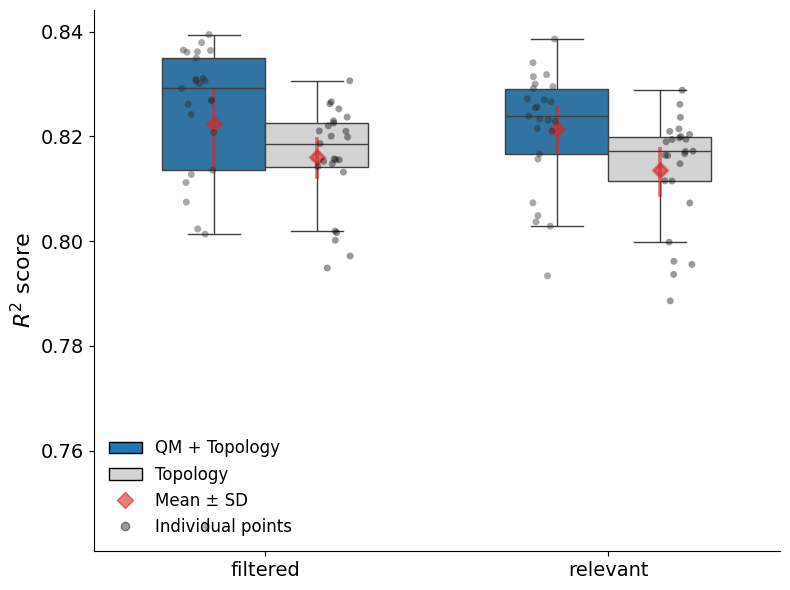

In [32]:
boxplot(huber_metric_df, "test_r2")

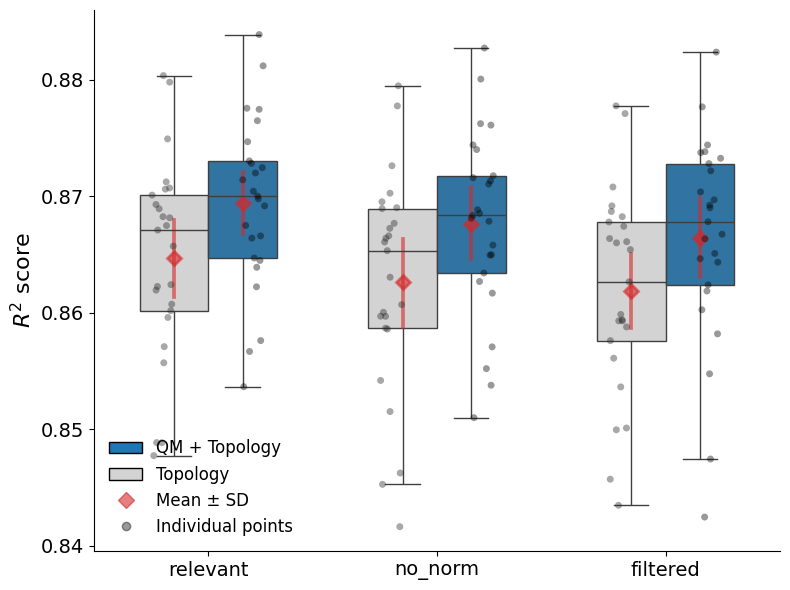

In [33]:
boxplot(krr_metric_df, "test_r2")

In [34]:
def filter_X_topo(X: pd.DataFrame, rdkit_features_file: Path) -> pd.DataFrame:
    import json, re
    import numpy as np
    
    with rdkit_features_file.open("r") as f:
        rdkit_feature_list: list[str] = json.load(f)

    pattern = "|".join(rdkit_feature_list)
    mask = np.array([bool(re.search(pattern, feature)) for feature in X.columns])

    return X.iloc[:, mask]  # only topological features remaining

In [35]:
from ml_enhance import get_topology_features
import re

best_fold = KRR_combo_relevant_no_norm_df["test_r2"].argmax()
best_estimator = KRR_combo_relevant_no_norm_df.loc[best_fold, "estimator"].best_estimator_
features = best_estimator[:-1].get_feature_names_out()

topo_features = get_topology_features()
pattern = "|".join(topo_features)
mask = np.array([bool(re.search(pattern, feature)) for feature in features])
features[~mask]
features.shape

(225,)

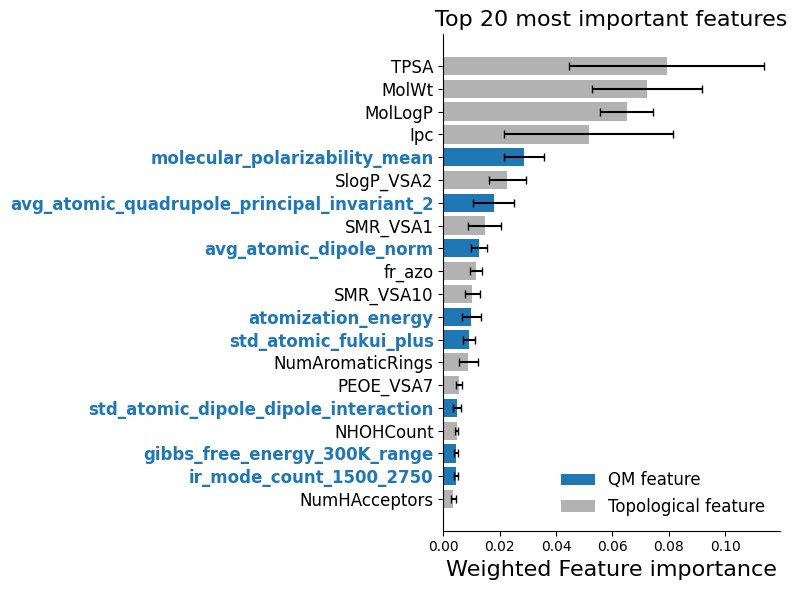

In [36]:
krr_fi_data = pd.read_pickle(r"..\data\KRR_results\KRR_combo_filtered_PFI_results.pkl")

FI = FeatureImportance(KRR_combo_filtered_df, provided_FI=krr_fi_data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

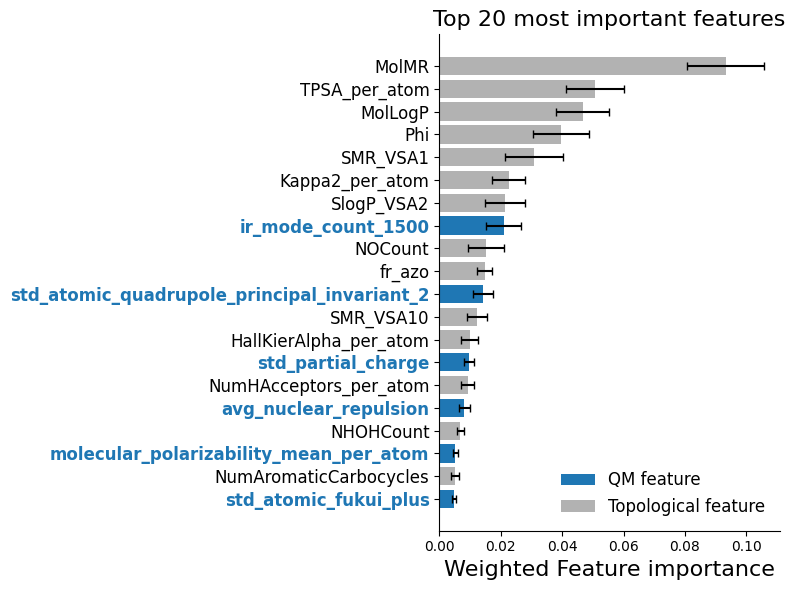

In [37]:
krr_fi_data = pd.read_pickle(r"..\data\KRR_results\KRR_combo_relevant_PFI_results.pkl")

FI = FeatureImportance(KRR_combo_relevant_df, provided_FI=krr_fi_data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

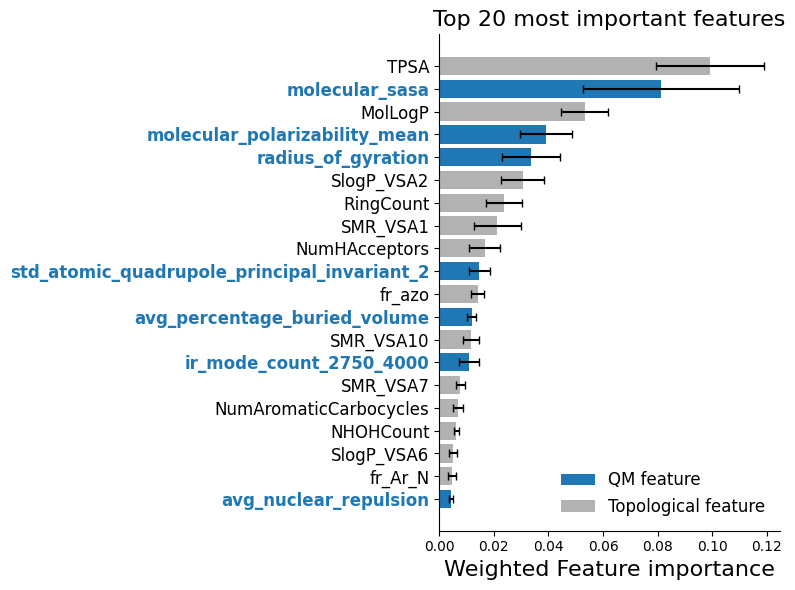

In [ ]:
krr_fi_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_no_norm_PFI_results.csv")

groups = krr_fi_data[["fold_id", "feature", "r2_mean"]]
FI_dict = {
    fold_id: df.set_index("feature")["r2_mean"]
    for fold_id, df in groups.groupby("fold_id")
}

FI = FeatureImportance(KRR_combo_relevant_no_norm_df, provided_FI=FI_dict)
fi_df = FI.get_feature_importance(20)
FI.plot(20)